In [1]:
print('Hello World')

Hello World


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [30]:
df = pd.read_csv('Electric_Production.csv.xls')

In [6]:
df.head(10)

,DATE,IPG2211A2N
0,1/1/1985,72.5052
1,2/1/1985,70.6720
2,3/1/1985,62.4502
3,4/1/1985,57.4714
4,5/1/1985,55.3151
5,6/1/1985,58.0904
6,7/1/1985,62.6202
7,8/1/1985,63.2485
8,9/1/1985,60.5846
9,10/1/1985,56.3154


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 397 entries, 0 to 396
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DATE        397 non-null    str    
 1   IPG2211A2N  397 non-null    float64
dtypes: float64(1), str(1)
memory usage: 6.3 KB


In [31]:
df.columns = ['Date', 'Production']
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

In [11]:
df.head(10)

,Date,Production
0,1985-01-01,72.5052
1,1985-02-01,70.6720
2,1985-03-01,62.4502
3,1985-04-01,57.4714
4,1985-05-01,55.3151
5,1985-06-01,58.0904
6,1985-07-01,62.6202
7,1985-08-01,63.2485
8,1985-09-01,60.5846
9,1985-10-01,56.3154


In [12]:
df.isnull().sum()

Date          0
Production    0
dtype: int64

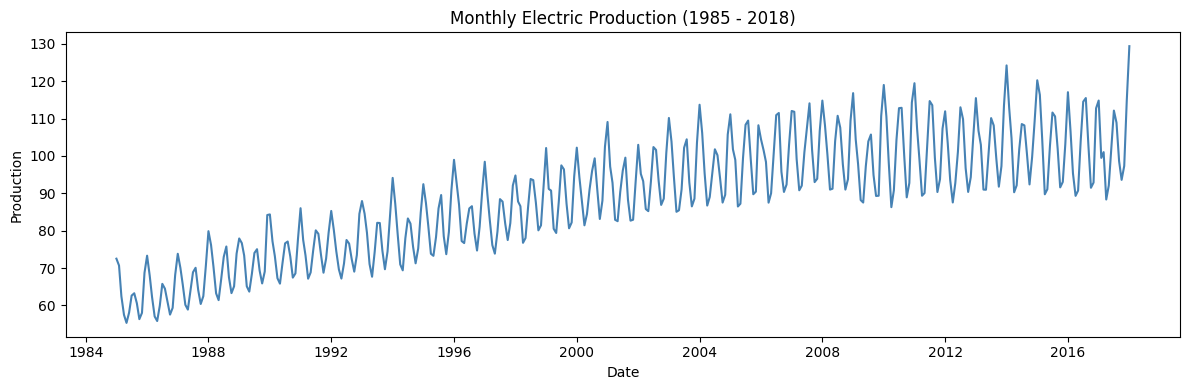

In [23]:
plt.figure(figsize=(12, 4))
plt.plot(df['Date'], df['Production'], color='steelblue')
plt.title('Monthly Electric Production (1985 - 2018)')
plt.xlabel('Date')
plt.ylabel('Production')
plt.tight_layout()
plt.show()

In [32]:
df['Month'] = df['Date'].dt.month
monthly_avg = df.groupby('Month')['Production'].mean()

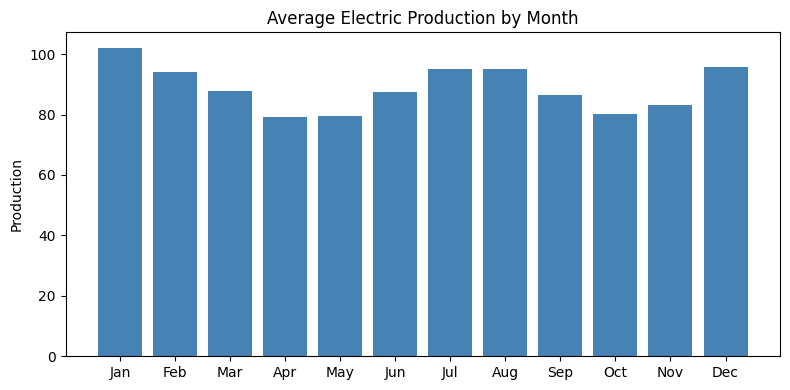

In [24]:

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(8, 4))
plt.bar(month_names, monthly_avg.values, color='steelblue')
plt.title('Average Electric Production by Month')
plt.ylabel('Production')
plt.tight_layout()
plt.show()

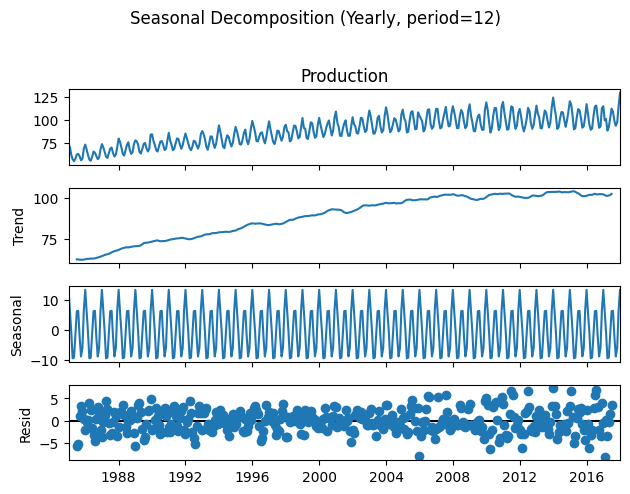

In [33]:
from statsmodels.tsa.seasonal import seasonal_decompose

ts = df.set_index('Date')['Production']

result = seasonal_decompose(ts, model='additive', period=12)
result.plot()
plt.suptitle('Seasonal Decomposition (Yearly, period=12)', y=1.02)
plt.tight_layout()
plt.show()

In [35]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df['Production'])

print("ADF Statistic :", round(adf_result[0], 4))
print("p-value       :", round(adf_result[1], 4))

if adf_result[1] < 0.05:
    print("\nData is STATIONARY (p < 0.05) → d = 0")
    d = 0
else:
    print("\n Data is NOT stationary (p > 0.05) → d = 1 (need differencing)")
    d=1


ADF Statistic : -2.257
p-value       : 0.1862

 Data is NOT stationary (p > 0.05) → d = 1 (need differencing)


In [36]:
split = len(df) - 24

train = df.iloc[:split].copy()
test  = df.iloc[split:].copy()

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

actual = test['Production'].values

def calc_metrics(name, actual, predicted):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return {'Model': name, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2), 'MAPE(%)': round(mape, 2)}

results = []

In [38]:
from statsmodels.tsa.arima.model import ARIMA

train_series = train.set_index('Date')['Production']

best_aic = np.inf
best_order = None

for p in [1, 2, 3, 4]:
    for q in [0, 1, 2]:
        try:
            model = ARIMA(train_series, order=(p, d, q))
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = (p, d, q)
                print(f"  ARIMA{(p,d,q)} — AIC: {round(fitted.aic, 2)} ")
        except:
            pass

print(f"\n Best ARIMA order: {best_order}")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

  ARIMA(1, 1, 0) — AIC: 2505.28 
  ARIMA(1, 1, 1) — AIC: 2438.88 
  ARIMA(1, 1, 2) — AIC: 2328.32 
  ARIMA(2, 1, 0) — AIC: 2275.82 
  ARIMA(2, 1, 1) — AIC: 2076.23 
  ARIMA(2, 1, 2) — AIC: 1942.18 


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.f

  ARIMA(3, 1, 2) — AIC: 1939.08 
  ARIMA(4, 1, 2) — AIC: 1935.55 

 Best ARIMA order: (4, 1, 2)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [39]:
arima_model = ARIMA(train_series, order=best_order)
arima_fit   = arima_model.fit()
arima_pred  = arima_fit.forecast(steps=24).values

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [40]:
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:             Production   No. Observations:                  373
Model:                 ARIMA(4, 1, 2)   Log Likelihood                -960.777
Date:                Fri, 24 Apr 2026   AIC                           1935.554
Time:                        10:58:24   BIC                           1962.987
Sample:                    01-01-1985   HQIC                          1946.449
                         - 01-01-2016                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7791      0.058     13.513      0.000       0.666       0.892
ar.L2         -0.9887      0.066    -14.892      0.000      -1.119      -0.859
ar.L3         -0.0109      0.066     -0.165      0.8

In [41]:
arima_metrics = calc_metrics('ARIMA', actual, arima_pred)
results.append(arima_metrics)

print("ARIMA Results:")
print(f"  MAE  : {arima_metrics['MAE']}")
print(f"  RMSE : {arima_metrics['RMSE']}")
print(f"  MAPE : {arima_metrics['MAPE(%)']}%")

ARIMA Results:
  MAE  : 4.28
  RMSE : 5.52
  MAPE : 4.11%


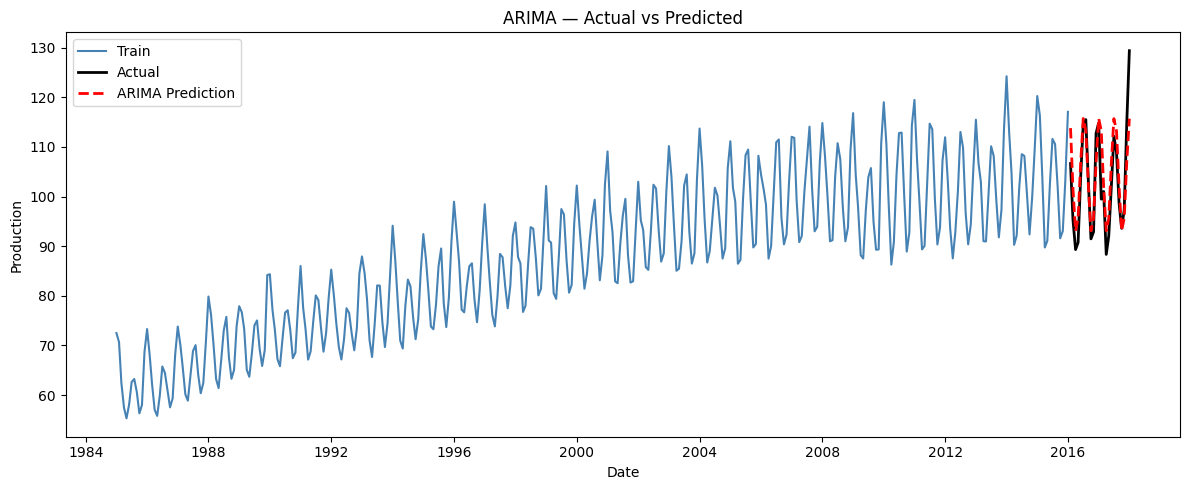

In [42]:
plt.figure(figsize=(12, 5))
plt.plot(train['Date'], train['Production'], color='steelblue', label='Train')
plt.plot(test['Date'], actual, color='black', linewidth=2, label='Actual')
plt.plot(test['Date'], arima_pred, color='red', linewidth=2, linestyle='--', label='ARIMA Prediction')
plt.title('ARIMA — Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA with seasonal period = 12
sarima_model = SARIMAX(train_series,order=best_order,seasonal_order=(1, 1, 1, 12))

sarima_fit = sarima_model.fit(disp=False)

print("finished fitiing")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('N

finished fitiing


In [44]:
# Forecast
sarima_pred = sarima_fit.forecast(steps=24).values

print("SARIMA Forecast (first 6 months):")
for i in range(6):
    print(f"  {test['Date'].iloc[i].strftime('%b %Y')} : {round(sarima_pred[i], 2)}")

SARIMA Forecast (first 6 months):
  Feb 2016 : 111.25
  Mar 2016 : 102.39
  Apr 2016 : 90.7
  May 2016 : 92.41
  Jun 2016 : 103.0
  Jul 2016 : 111.87


In [45]:
sarima_metrics = calc_metrics('SARIMA', actual, sarima_pred)
results.append(sarima_metrics)

print("SARIMA Results:")
print(f" MAE  : {sarima_metrics['MAE']}")
print(f" RMSE : {sarima_metrics['RMSE']}")
print(f" MAPE : {sarima_metrics['MAPE(%)']}%")

SARIMA Results:
 MAE  : 3.25
 RMSE : 4.37
 MAPE : 3.08%


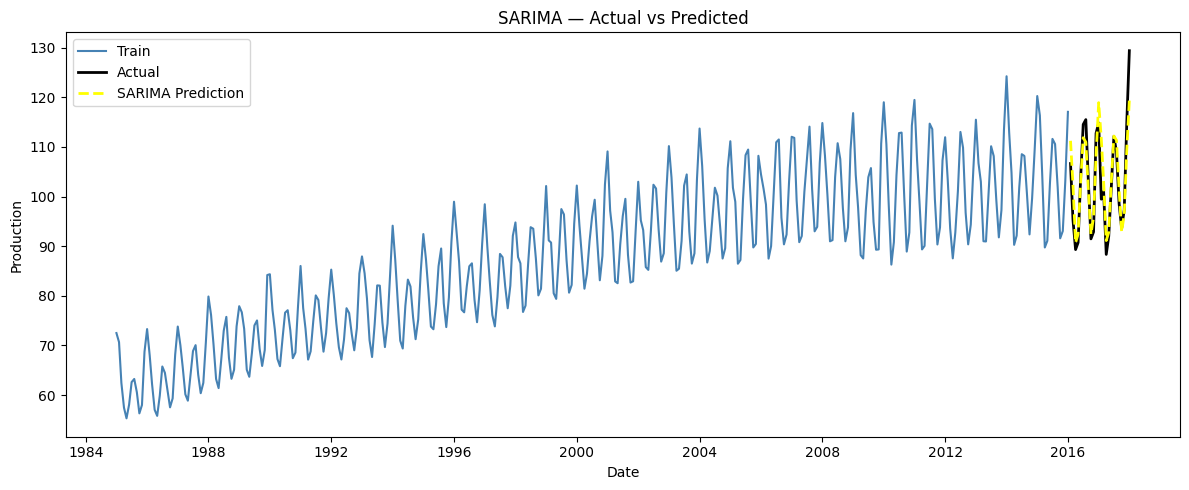

In [46]:
plt.figure(figsize=(12, 5))
plt.plot(train['Date'], train['Production'], color='steelblue', label='Train')
plt.plot(test['Date'], actual, color='black', linewidth=2, label='Actual')
plt.plot(test['Date'], sarima_pred, color='yellow', linewidth=2, linestyle='--', label='SARIMA Prediction')
plt.title('SARIMA — Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.tight_layout()
plt.show()

In [47]:
from prophet import Prophet

prophet_train = train[['Date', 'Production']].copy()
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(yearly_seasonality=True,weekly_seasonality=False,daily_seasonality=False)

prophet_model.fit(prophet_train)
print("model fitted!")

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.
11:03:47 - cmdstanpy - INFO - Chain [1] start processing
11:03:48 - cmdstanpy - INFO - Chain [1] done processing


model fitted!


In [48]:
# Create future dates and predict
future = prophet_model.make_future_dataframe(periods=24, freq='MS')
prophet_result = prophet_model.predict(future)

# Get test period predictions
prophet_pred = prophet_result['yhat'].iloc[-24:].values

print("Prophet Forecast (first 6 months):")
for i in range(6):
    print(f"  {test['Date'].iloc[i].strftime('%b %Y')} : {round(prophet_pred[i], 2)}")

Prophet Forecast (first 6 months):
  Feb 2016 : 110.43
  Mar 2016 : 102.7
  Apr 2016 : 94.82
  May 2016 : 95.04
  Jun 2016 : 102.35
  Jul 2016 : 108.91


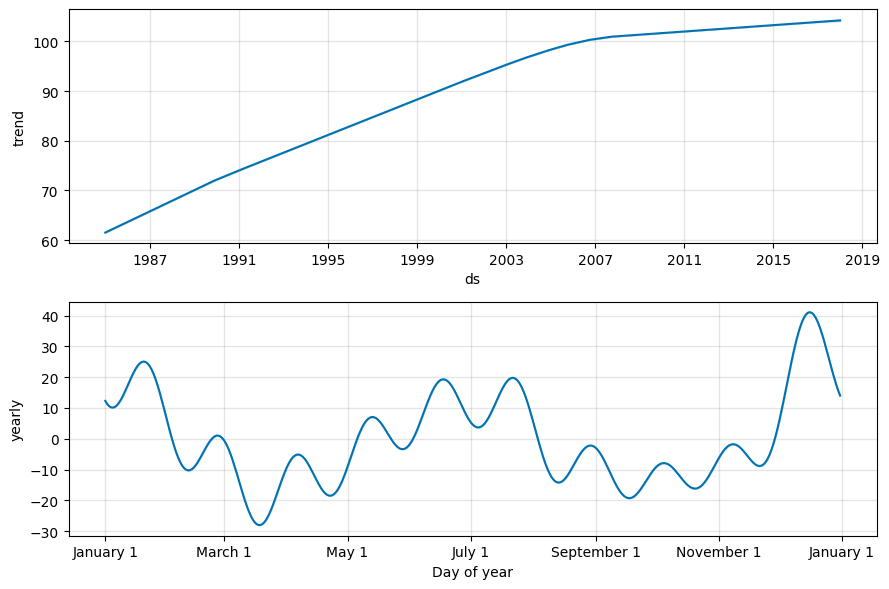

In [49]:
prophet_model.plot_components(prophet_result)
plt.tight_layout()
plt.show()

In [50]:
prophet_metrics = calc_metrics('Prophet', actual, prophet_pred)
results.append(prophet_metrics)

print("Prophet Results:")
print(f"  MAE  : {prophet_metrics['MAE']}")
print(f"  RMSE : {prophet_metrics['RMSE']}")
print(f"  MAPE : {prophet_metrics['MAPE(%)']}%")

Prophet Results:
  MAE  : 3.96
  RMSE : 4.93
  MAPE : 3.84%


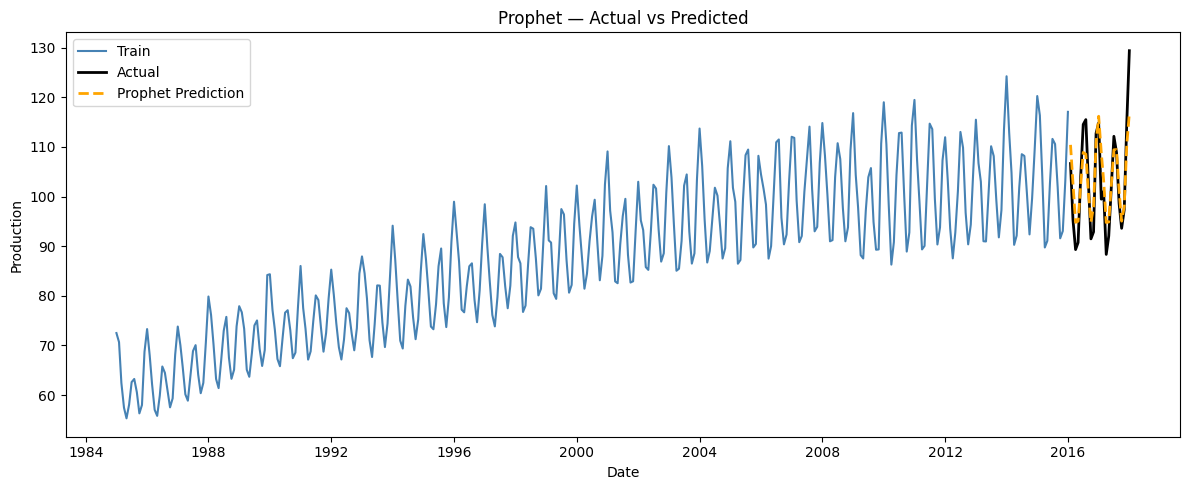

In [51]:
plt.figure(figsize=(12, 5))
plt.plot(train['Date'], train['Production'], color='steelblue', label='Train')
plt.plot(test['Date'], actual, color='black', linewidth=2, label='Actual')
plt.plot(test['Date'], prophet_pred, color='orange', linewidth=2, linestyle='--', label='Prophet Prediction')
plt.title('Prophet — Actual vs Predicted')
plt.xlabel('Date')
plt.ylabel('Production')
plt.legend()
plt.tight_layout()
plt.show()

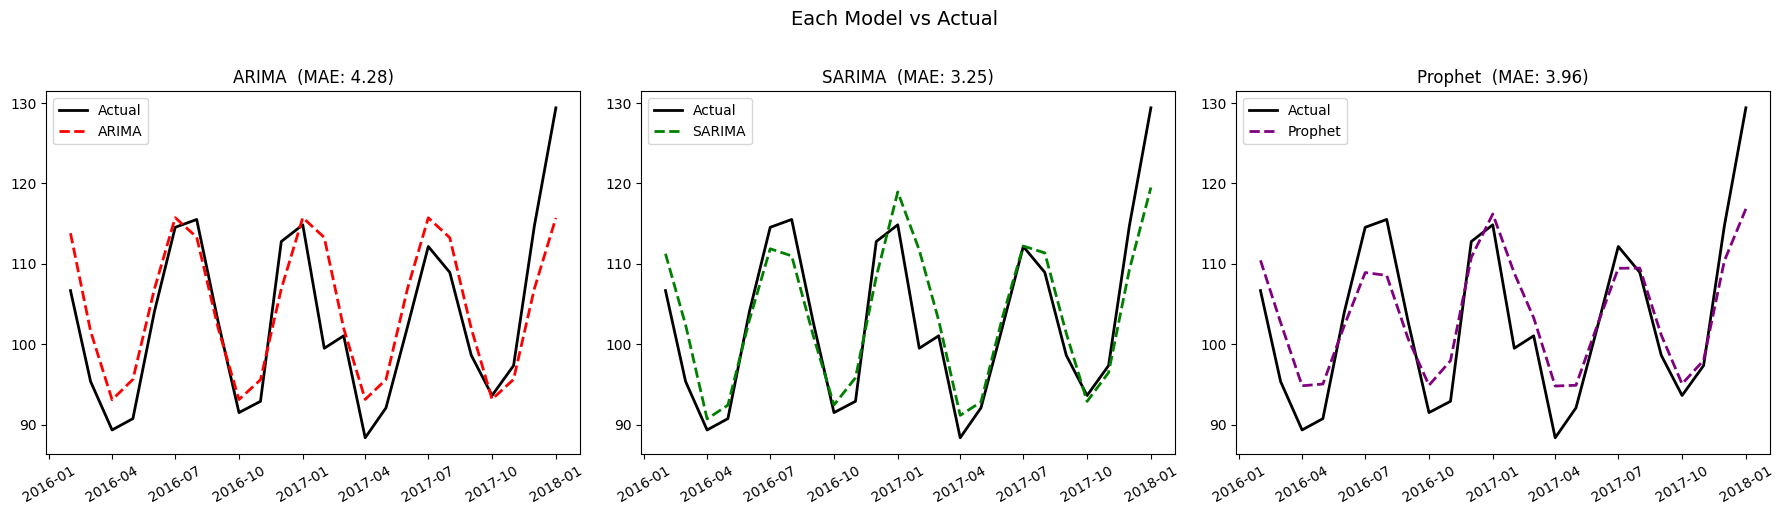

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ARIMA
axes[0].plot(test['Date'], actual, color='black', linewidth=2, label='Actual')
axes[0].plot(test['Date'], arima_pred, color='red', linewidth=2, linestyle='--', label='ARIMA')
axes[0].set_title(f"ARIMA  (MAE: {arima_metrics['MAE']})", fontsize=12)
axes[0].legend()
axes[0].tick_params(axis='x', rotation=30)

# SARIMA
axes[1].plot(test['Date'], actual, color='black', linewidth=2, label='Actual')
axes[1].plot(test['Date'], sarima_pred, color='green', linewidth=2, linestyle='--', label='SARIMA')
axes[1].set_title(f"SARIMA  (MAE: {sarima_metrics['MAE']})", fontsize=12)
axes[1].legend()
axes[1].tick_params(axis='x', rotation=30)

# Prophet
axes[2].plot(test['Date'], actual, color='black', linewidth=2, label='Actual')
axes[2].plot(test['Date'], prophet_pred, color='purple', linewidth=2, linestyle='--', label='Prophet')
axes[2].set_title(f"Prophet  (MAE: {prophet_metrics['MAE']})", fontsize=12)
axes[2].legend()
axes[2].tick_params(axis='x', rotation=30)

plt.suptitle('Each Model vs Actual', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()